In [1]:
!pip install -q joblib

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.multioutput import MultiOutputClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

In [2]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(df.shape)
df.head()

Saving child.csv to child.csv
(8000, 16)


,age_months,weight_kg,fever_present,fever_duration_days,respiratory_rate_bpm,chest_indrawing,ability_to_drink_feed,vomiting_everything,convulsions,lethargic_or_unconscious,diarrhea_duration_days,dehydration_signs,spo2_percent,malnutrition_indicator,clinical_disposition,severity_score
0,19,7.3,No,0,43.6,No,Reduced,No,No,No,4,NaN,93.7,Moderate,Treat + monitor,Medium
1,42,12.9,Yes,2,35.1,No,Reduced,No,No,No,3,Some,92.1,NaN,Treat + monitor,Medium
2,18,10.6,No,1,37.8,No,Normal,No,No,No,0,NaN,96.9,NaN,Treat locally,Low
3,14,8.0,Yes,2,38.1,No,Normal,No,No,No,6,NaN,96.1,NaN,Treat + monitor,Low
4,10,8.0,No,2,45.8,No,Normal,No,No,No,3,Severe,94.6,NaN,Stabilize + refer,Medium


In [12]:
expected_cols = [
    'age_months',
    'weight_kg',
    'fever_present',
    'fever_duration_days',
    'respiratory_rate_bpm',
    'chest_indrawing',
    'ability_to_drink_feed',
    'vomiting_everything',
    'convulsions',
    'lethargic_or_unconscious',
    'diarrhea_duration_days',
    'dehydration_signs',
    'spo2_percent',
    'malnutrition_indicator',
    'clinical_disposition',
    'severity_score'
]

missing_cols = [col for col in expected_cols if col not in df.columns]
extra_cols = [col for col in df.columns if col not in expected_cols]

print("Missing columns:", missing_cols)
print("Extra columns:", extra_cols)

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[expected_cols].copy()
df = df.drop_duplicates().reset_index(drop=True)

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

print("Cleaned dataset shape:", df.shape)
display(df.head())

Missing columns: []
Extra columns: []
Cleaned dataset shape: (8000, 16)


,age_months,weight_kg,fever_present,fever_duration_days,respiratory_rate_bpm,chest_indrawing,ability_to_drink_feed,vomiting_everything,convulsions,lethargic_or_unconscious,diarrhea_duration_days,dehydration_signs,spo2_percent,malnutrition_indicator,clinical_disposition,severity_score
0,19,7.3,No,0,43.6,No,Reduced,No,No,No,4,nan,93.7,Moderate,Treat + monitor,Medium
1,42,12.9,Yes,2,35.1,No,Reduced,No,No,No,3,Some,92.1,nan,Treat + monitor,Medium
2,18,10.6,No,1,37.8,No,Normal,No,No,No,0,nan,96.9,nan,Treat locally,Low
3,14,8.0,Yes,2,38.1,No,Normal,No,No,No,6,nan,96.1,nan,Treat + monitor,Low
4,10,8.0,No,2,45.8,No,Normal,No,No,No,3,Severe,94.6,nan,Stabilize + refer,Medium


In [13]:
print("clinical_disposition distribution:")
display(df["clinical_disposition"].value_counts())

print("\nseverity_score distribution:")
display(df["severity_score"].value_counts())

print("\nCombined distribution:")
combined = df["clinical_disposition"] + " | " + df["severity_score"]
display(combined.value_counts())

clinical_disposition distribution:


,count
clinical_disposition,
Treat + monitor,2000
Treat locally,2000
Stabilize + refer,2000
Emergency referral,2000



severity_score distribution:


,count
severity_score,
Low,3150
High,2935
Medium,1915



Combined distribution:


,count
Treat locally | Low,2000
Emergency referral | High,2000
Treat + monitor | Low,1150
Stabilize + refer | Medium,1065
Stabilize + refer | High,935
Treat + monitor | Medium,850


In [14]:
clinical_order = [
    'Treat locally',
    'Treat + monitor',
    'Stabilize + refer',
    'Emergency referral'
]

severity_order = ['Low', 'Medium', 'High']

clinical_map = {label: idx for idx, label in enumerate(clinical_order)}
severity_map = {label: idx for idx, label in enumerate(severity_order)}

inv_clinical = {v: k for k, v in clinical_map.items()}
inv_severity = {v: k for k, v in severity_map.items()}

bad_clinical = sorted(set(df['clinical_disposition']) - set(clinical_order))
bad_severity = sorted(set(df['severity_score']) - set(severity_order))

if bad_clinical:
    raise ValueError(f"Unexpected clinical_disposition labels found: {bad_clinical}")
if bad_severity:
    raise ValueError(f"Unexpected severity_score labels found: {bad_severity}")

X = df.drop(['clinical_disposition', 'severity_score'], axis=1)

y = pd.DataFrame({
    'clinical_disposition': df['clinical_disposition'].map(clinical_map),
    'severity_score': df['severity_score'].map(severity_map)
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Feature shape: (8000, 14)
Target shape: (8000, 2)


,age_months,weight_kg,fever_present,fever_duration_days,respiratory_rate_bpm,chest_indrawing,ability_to_drink_feed,vomiting_everything,convulsions,lethargic_or_unconscious,diarrhea_duration_days,dehydration_signs,spo2_percent,malnutrition_indicator
0,19,7.3,No,0,43.6,No,Reduced,No,No,No,4,nan,93.7,Moderate
1,42,12.9,Yes,2,35.1,No,Reduced,No,No,No,3,Some,92.1,nan
2,18,10.6,No,1,37.8,No,Normal,No,No,No,0,nan,96.9,nan
3,14,8.0,Yes,2,38.1,No,Normal,No,No,No,6,nan,96.1,nan
4,10,8.0,No,2,45.8,No,Normal,No,No,No,3,Severe,94.6,nan


,clinical_disposition,severity_score
0,1,1
1,1,1
2,0,0
3,1,0
4,2,1


In [15]:
stratify_key = df['clinical_disposition'].astype(str) + "_" + df['severity_score'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_key
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (6400, 14)
X_test : (1600, 14)
y_train: (6400, 2)
y_test : (1600, 2)


In [16]:
numeric_cols = [
    'age_months',
    'weight_kg',
    'fever_duration_days',
    'respiratory_rate_bpm',
    'diarrhea_duration_days',
    'spo2_percent'
]

categorical_cols = [
    'fever_present',
    'chest_indrawing',
    'ability_to_drink_feed',
    'vomiting_everything',
    'convulsions',
    'lethargic_or_unconscious',
    'dehydration_signs',
    'malnutrition_indicator'
]

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [17]:
models = {
    "logistic": LogisticRegression(max_iter=3000),
    "rf": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "extra": ExtraTreesClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ('prep', preprocessor),
        ('model', MultiOutputClassifier(model))
    ])

print("Models prepared:", list(pipelines.keys()))

Models prepared: ['logistic', 'rf', 'extra']


In [18]:
trained = {}

for name, pipe in pipelines.items():
    print(f"Training {name}...")
    pipe.fit(X_train, y_train)
    trained[name] = pipe

print("All models trained.")

Training logistic...
Training rf...
Training extra...
All models trained.


In [19]:
def evaluate_model(model, name):
    pred = model.predict(X_test)

    y_true_disp = y_test['clinical_disposition'].values
    y_true_sev = y_test['severity_score'].values

    y_pred_disp = pred[:, 0]
    y_pred_sev = pred[:, 1]

    disp_f1 = f1_score(y_true_disp, y_pred_disp, average='macro')
    sev_f1 = f1_score(y_true_sev, y_pred_sev, average='macro')
    composite = 0.65 * disp_f1 + 0.35 * sev_f1

    print("\n" + "="*80)
    print(f"MODEL: {name}")
    print("="*80)
    print(f"Disposition F1: {disp_f1:.6f}")
    print(f"Severity F1   : {sev_f1:.6f}")
    print(f"Composite     : {composite:.6f}")

    print("\nDisposition Report")
    print(classification_report(
        y_true_disp,
        y_pred_disp,
        target_names=clinical_order,
        digits=4
    ))

    print("\nSeverity Report")
    print(classification_report(
        y_true_sev,
        y_pred_sev,
        target_names=severity_order,
        digits=4
    ))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    cm_disp = confusion_matrix(y_true_disp, y_pred_disp, labels=list(range(len(clinical_order))))
    disp_plot = ConfusionMatrixDisplay(confusion_matrix=cm_disp, display_labels=clinical_order)
    disp_plot.plot(ax=axes[0], xticks_rotation=30, colorbar=False)
    axes[0].set_title(f"{name} - clinical_disposition")

    cm_sev = confusion_matrix(y_true_sev, y_pred_sev, labels=list(range(len(severity_order))))
    sev_plot = ConfusionMatrixDisplay(confusion_matrix=cm_sev, display_labels=severity_order)
    sev_plot.plot(ax=axes[1], xticks_rotation=30, colorbar=False)
    axes[1].set_title(f"{name} - severity_score")

    plt.tight_layout()
    plt.show()

    return {
        "model": name,
        "disposition_f1": disp_f1,
        "severity_f1": sev_f1,
        "composite_score": composite
    }


MODEL: logistic
Disposition F1: 0.925039
Severity F1   : 0.951143
Composite     : 0.934175

Disposition Report
                    precision    recall  f1-score   support

     Treat locally     0.8962    0.9500    0.9223       400
   Treat + monitor     0.9128    0.8900    0.9013       400
 Stabilize + refer     0.9302    0.9325    0.9313       400
Emergency referral     0.9636    0.9275    0.9452       400

          accuracy                         0.9250      1600
         macro avg     0.9257    0.9250    0.9250      1600
      weighted avg     0.9257    0.9250    0.9250      1600


Severity Report
              precision    recall  f1-score   support

         Low     0.9656    0.9794    0.9724       630
      Medium     0.9202    0.9034    0.9117       383
        High     0.9709    0.9676    0.9693       587

    accuracy                         0.9569      1600
   macro avg     0.9522    0.9501    0.9511      1600
weighted avg     0.9567    0.9569    0.9567      1600



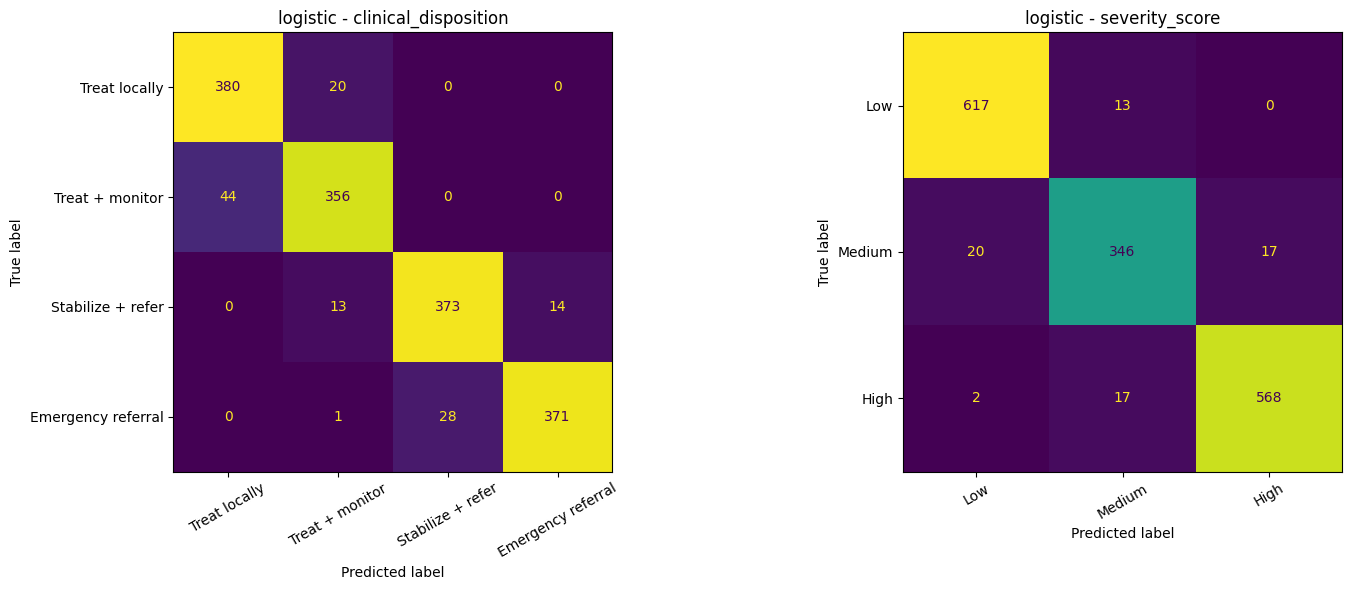


MODEL: rf
Disposition F1: 0.993129
Severity F1   : 0.974552
Composite     : 0.986627

Disposition Report
                    precision    recall  f1-score   support

     Treat locally     1.0000    0.9950    0.9975       400
   Treat + monitor     0.9852    1.0000    0.9926       400
 Stabilize + refer     0.9876    0.9925    0.9900       400
Emergency referral     1.0000    0.9850    0.9924       400

          accuracy                         0.9931      1600
         macro avg     0.9932    0.9931    0.9931      1600
      weighted avg     0.9932    0.9931    0.9931      1600


Severity Report
              precision    recall  f1-score   support

         Low     0.9904    0.9841    0.9873       630
      Medium     0.9437    0.9634    0.9535       383
        High     0.9863    0.9796    0.9829       587

    accuracy                         0.9775      1600
   macro avg     0.9735    0.9757    0.9746      1600
weighted avg     0.9777    0.9775    0.9776      1600



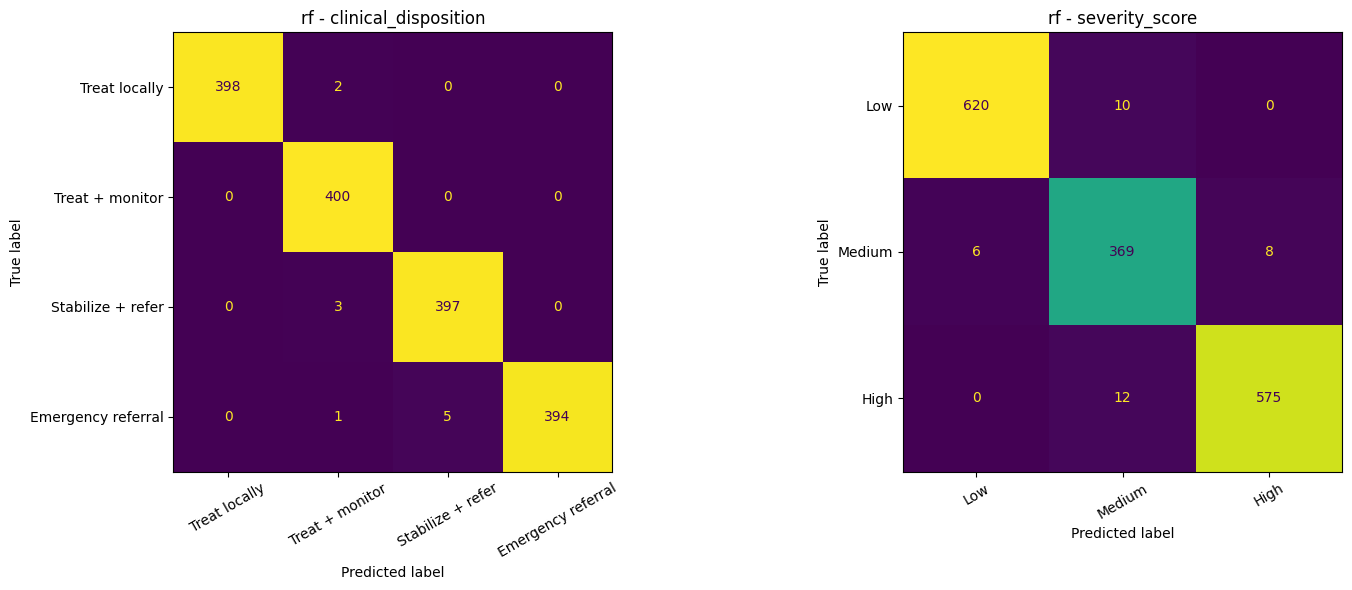


MODEL: extra
Disposition F1: 0.952986
Severity F1   : 0.956550
Composite     : 0.954233

Disposition Report
                    precision    recall  f1-score   support

     Treat locally     0.9684    0.9950    0.9815       400
   Treat + monitor     0.9485    0.9675    0.9579       400
 Stabilize + refer     0.9175    0.9450    0.9310       400
Emergency referral     0.9810    0.9050    0.9415       400

          accuracy                         0.9531      1600
         macro avg     0.9539    0.9531    0.9530      1600
      weighted avg     0.9539    0.9531    0.9530      1600


Severity Report
              precision    recall  f1-score   support

         Low     0.9796    0.9921    0.9858       630
      Medium     0.9149    0.9269    0.9209       383
        High     0.9739    0.9523    0.9630       587

    accuracy                         0.9619      1600
   macro avg     0.9561    0.9571    0.9565      1600
weighted avg     0.9620    0.9619    0.9619      1600



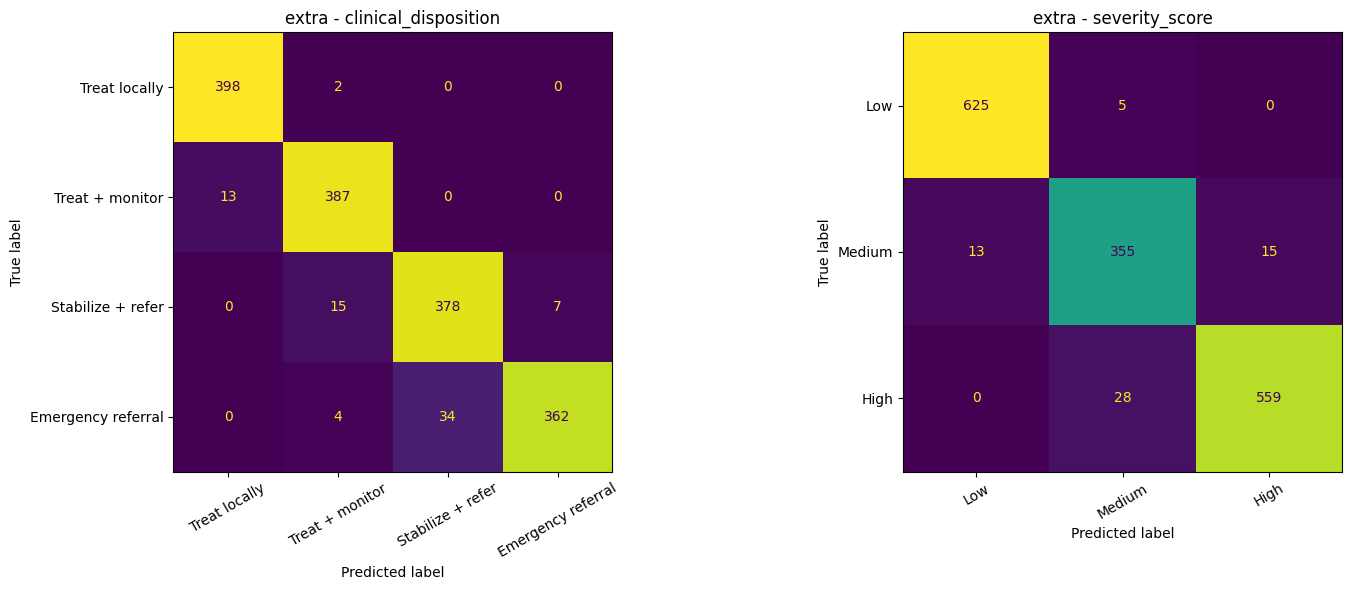


Final comparison:


,model,disposition_f1,severity_f1,composite_score
0,rf,0.993129,0.974552,0.986627
1,extra,0.952986,0.956550,0.954233
2,logistic,0.925039,0.951143,0.934175


In [20]:
results = []

for name, model in trained.items():
    result = evaluate_model(model, name)
    results.append(result)

results_df = pd.DataFrame(results).sort_values(
    by="composite_score",
    ascending=False
).reset_index(drop=True)

print("\nFinal comparison:")
display(results_df)

In [21]:
best_name = results_df.iloc[0]["model"]
best_model = trained[best_name]

print("Best model selected:", best_name)

Best model selected: rf


In [22]:
bundle = {
    "model": best_model,
    "features": X.columns.tolist(),
    "inv_clinical": inv_clinical,
    "inv_severity": inv_severity,
    "clinical_order": clinical_order,
    "severity_order": severity_order
}

joblib.dump(bundle, "child_model.joblib")
print("Saved as child_model.joblib")

files.download("child_model.joblib")

Saved as child_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
sample = {
    'age_months': 18,
    'weight_kg': 8.5,
    'fever_present': 'Yes',
    'fever_duration_days': 3,
    'respiratory_rate_bpm': 52,
    'chest_indrawing': 'Yes',
    'ability_to_drink_feed': 'Reduced',
    'vomiting_everything': 'No',
    'convulsions': 'No',
    'lethargic_or_unconscious': 'No',
    'diarrhea_duration_days': 1,
    'dehydration_signs': 'Some',
    'spo2_percent': 91,
    'malnutrition_indicator': 'Yes'
}

sample_df = pd.DataFrame([sample])

pred = best_model.predict(sample_df)[0]

predicted_clinical = inv_clinical[int(pred[0])]
predicted_severity = inv_severity[int(pred[1])]

print("Predicted clinical_disposition:", predicted_clinical)
print("Predicted severity_score      :", predicted_severity)

Predicted clinical_disposition: Stabilize + refer
Predicted severity_score      : High


In [24]:
proba_list = best_model.predict_proba(sample_df)

disp_probs = proba_list[0][0]
sev_probs = proba_list[1][0]

disp_df = pd.DataFrame({
    "clinical_disposition": clinical_order,
    "probability": disp_probs
}).sort_values("probability", ascending=False).reset_index(drop=True)

sev_df = pd.DataFrame({
    "severity_score": severity_order,
    "probability": sev_probs
}).sort_values("probability", ascending=False).reset_index(drop=True)

print("clinical_disposition probabilities:")
display(disp_df)

print("severity_score probabilities:")
display(sev_df)

clinical_disposition probabilities:


,clinical_disposition,probability
0,Stabilize + refer,0.98
1,Emergency referral,0.02
2,Treat + monitor,0.00
3,Treat locally,0.00


severity_score probabilities:


,severity_score,probability
0,High,0.956667
1,Medium,0.043333
2,Low,0.000000
